## IAPUCP - Modelos IA
### Autoencoders - Denoise

In [1]:
# Cargo librerias
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision.datasets as Datasets

In [2]:
# Dataset cifar
#  train
training_set = Datasets.CIFAR10(root='./', download=True,
                                transform=transforms.ToTensor())

#  test
test_set = Datasets.CIFAR10(root='./', download=True, train=False,
                                  transform=transforms.ToTensor())

In [3]:
# Ejecutar en gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

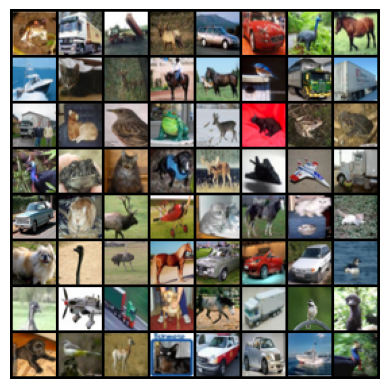

In [4]:
# se muestra un batch de imagenes de entrenamiento
def show_batch(imgs):
    if isinstance(imgs, np.ndarray):
        imgs = torch.tensor(imgs)
    if imgs.dtype == torch.uint8:
        imgs = imgs.float() / 255.0  # Solo normaliza si es uint8
    grid = torchvision.utils.make_grid(imgs, nrow=8)
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()

# visualizo un batch pequeño del conjunto de entrenamiento
imgs = training_set.data[:64]  # 64 imágenes
imgs = np.transpose(imgs, (0, 3, 1, 2))  # (N, H, W, C) -> (N, C, H, W)
show_batch(imgs)


In [12]:
# Se genera noise a las imágenes
def add_noise(imgs):
    noise = torch.randn_like(imgs) * 0.05
    noisy_imgs = imgs + noise
    return torch.clamp(noisy_imgs, 0., 1.)

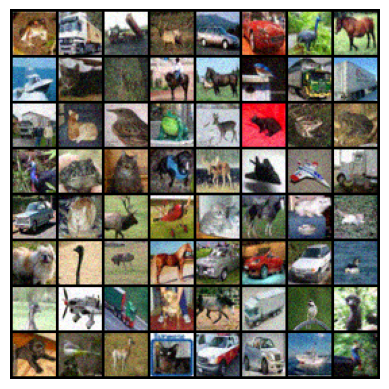

In [13]:
# se muestran un batch de imágenes con ruido
imgs = training_set.data[:64].transpose(0, 3, 1, 2)
imgs = torch.tensor(imgs).float() / 255.0  # convierte a tensor y normaliza
noisy_imgs = add_noise(imgs)
show_batch(noisy_imgs)

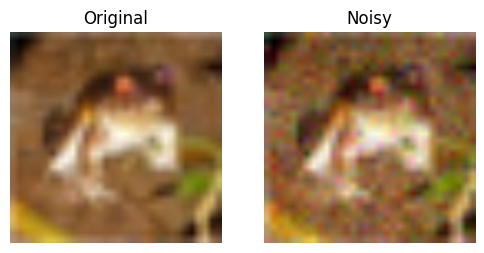

In [14]:
import torch.nn.functional as F

# Selecciona la primera imagen del batch y su versión con ruido
original = imgs[0]
noisy = noisy_imgs[0]

# Redimensiona para visualización
original = F.interpolate(original.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)
noisy = F.interpolate(noisy.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)

# Visualiza ambas imágenes
def show_original_and_noisy(original, noisy):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(np.transpose(original.cpu().numpy(), (1, 2, 0)))
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(np.transpose(noisy.cpu().numpy(), (1, 2, 0)))
    axes[1].set_title('Noisy')
    axes[1].axis('off')
    plt.show()

show_original_and_noisy(original, noisy)

In [8]:
# se usara cifar para la tarea de denoising
# se usara un autoencoder para eliminar el ruido

# se usara un modelo de autoencoder convolucional
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [9]:
# Proceso de entrenamiento del autoencoder

autoencoder = Autoencoder().to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_losses = []

# DataLoader para entrenamiento
train_loader = torch.utils.data.DataLoader(training_set, batch_size=64, shuffle=True)

epochs = 20
for epoch in range(epochs):
    autoencoder.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs)
        optimizer.zero_grad()
        outputs = autoencoder(noisy_imgs)
        loss = loss_fn(outputs, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    train_losses.append(epoch_loss)


Epoch 1/20, Loss: 0.0157
Epoch 2/20, Loss: 0.0068
Epoch 3/20, Loss: 0.0054
Epoch 4/20, Loss: 0.0047
Epoch 5/20, Loss: 0.0042
Epoch 6/20, Loss: 0.0037
Epoch 7/20, Loss: 0.0034
Epoch 8/20, Loss: 0.0032
Epoch 9/20, Loss: 0.0030
Epoch 10/20, Loss: 0.0028
Epoch 11/20, Loss: 0.0027
Epoch 12/20, Loss: 0.0026
Epoch 13/20, Loss: 0.0025
Epoch 14/20, Loss: 0.0024
Epoch 15/20, Loss: 0.0023
Epoch 16/20, Loss: 0.0022
Epoch 17/20, Loss: 0.0021
Epoch 18/20, Loss: 0.0020
Epoch 19/20, Loss: 0.0020
Epoch 20/20, Loss: 0.0019


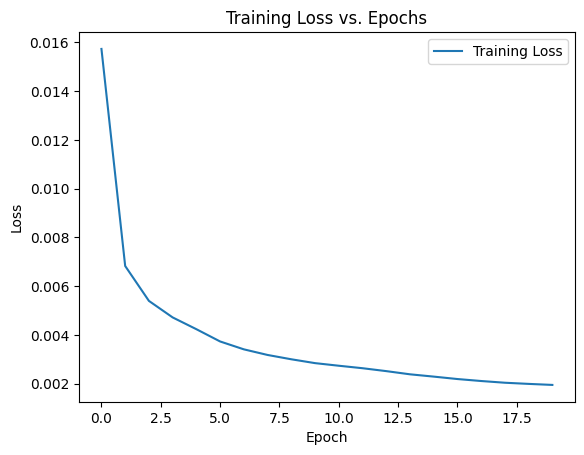

In [10]:
# Graficar las pérdidas de entrenamiento
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epochs")
plt.legend()
plt.show()


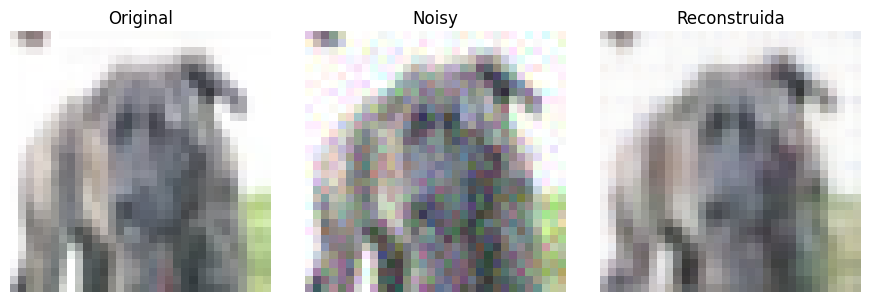

In [11]:
# Tomar un batch de imágenes del set de entrenamiento o test
imgs, _ = next(iter(train_loader))
imgs = imgs.to(device)
noisy_imgs = add_noise(imgs)
with torch.no_grad():
    reconstructed_imgs = autoencoder(noisy_imgs)

# Selecciona la primera imagen del batch
original = imgs[0].cpu()
noisy = noisy_imgs[0].cpu()
reconstructed = reconstructed_imgs[0].cpu()

# Visualiza las tres imágenes (original, noisy, reconstruida) correctamente alineadas
import matplotlib.pyplot as plt
import numpy as np

def show_images(original, noisy, reconstructed):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, img, title in zip(axes, [original, noisy, reconstructed], ['Original', 'Noisy', 'Reconstruida']):
        img_np = img.numpy()
        img_np = np.transpose(img_np, (1, 2, 0))
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images(original, noisy, reconstructed)